In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets nltk tensorflow

### Import Liabraries

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt

### Load Dataset

In [ ]:
file_path = "/content/drive/MyDrive/archive (5)/training.1600000.processed.noemoticon.csv"

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None
)

df.columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

df = df[["sentiment","text"]]

### Convert Labels

In [ ]:
df["sentiment"] = df["sentiment"].replace(4,1)

### Take 200000 Samples

In [ ]:
df = df.sample(200000, random_state=42, replace=True)

df.head()

,sentiment,text,clean_text
875821,1,camera obscura - if looks could kill - @tezzer...,camera obscura looks could kill says thursday ...
115482,0,@mredwards Ooo! Salem's Lot sounds fun. Too ...,ooo salems lot sounds fun bad gave paperbacks ...
1211104,1,disneyland tomorrow! and lots and lots of E3 ...,disneyland tomorrow lots lots e loooove
1203460,1,Chillin wÃ?th shawna theb off to newark jerzey...,chillin wth shawna theb newark jerzey boys
1102019,1,Chatting with friends,chatting friends


### Text Processing

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"@\w+","",text)
    text = re.sub(r"[^a-zA-Z ]","",text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Train Test Split

In [ ]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

### Naive Bayes

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)

nb_model = MultinomialNB()

nb_model.fit(X_train_vec,y_train)

nb_pred = nb_model.predict(X_test_vec)

nb_accuracy = accuracy_score(y_test,nb_pred)

print("Naive Bayes Accuracy:",nb_accuracy)

Naive Bayes Accuracy: 0.77615


### SVM Model

In [ ]:
svm_model = LinearSVC()

svm_model.fit(X_train_vec,y_train)

svm_pred = svm_model.predict(X_test_vec)

svm_accuracy = accuracy_score(y_test,svm_pred)

print("SVM Accuracy:",svm_accuracy)

SVM Accuracy: 0.798725


### LSTM

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Tokenization
tokenizer = Tokenizer(num_words=30000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=150)
X_test_pad = pad_sequences(X_test_seq, maxlen=150)

# Model
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=30000, output_dim=128))

lstm_model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1, activation="sigmoid"))

# Compile
lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Evaluate
loss, lstm_accuracy = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", lstm_accuracy)

Epoch 1/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 806s 356ms/step - accuracy: 0.7602 - loss: 0.4801 - val_accuracy: 0.8746 - val_loss: 0.2953
Epoch 2/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 720s 320ms/step - accuracy: 0.9093 - loss: 0.2245 - val_accuracy: 0.9184 - val_loss: 0.2107
Epoch 3/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 695s 309ms/step - accuracy: 0.9409 - loss: 0.1476 - val_accuracy: 0.9308 - val_loss: 0.1884
Epoch 4/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 697s 310ms/step - accuracy: 0.9583 - loss: 0.1065 - val_accuracy: 0.9423 - val_loss: 0.1832
Epoch 5/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 697s 310ms/step - accuracy: 0.9669 - loss: 0.0829 - val_accuracy: 0.9484 - val_loss: 0.1813
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - accuracy: 0.9481 - loss: 0.1886
LSTM Accuracy: 0.9489250183105469


# ROBERTa (Proposed)

In [ ]:
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import Trainer, TrainingArguments


# Prepare Data
X = df["clean_text"]
y = df["sentiment"]

train_texts, test_texts, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)


# Dataset Class
class Dataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)


# GPU support
device = "cuda" if torch.cuda.is_available() else "cpu"


# Load RoBERTa model
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)


# Training setup
training_args = TrainingArguments(

    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    weight_decay=0.01,

    logging_steps=500,

    eval_strategy="epoch", # Changed from evaluation_strategy

    save_strategy="no"
)


# Trainer
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)


# Train model
trainer.train()


# Evaluate accuracy
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

roberta_accuracy = accuracy_score(test_labels, preds)

print("RoBERTa Accuracy:", roberta_accuracy)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.325394,0.277107
2,0.216681,0.220800
3,0.156248,0.200453


RoBERTa Accuracy: 0.955225


### Accuracy of Four Models

In [ ]:
# Store accuracies
results = {
    "Naive Bayes": nb_accuracy,
    "SVM": svm_accuracy,
    "LSTM": lstm_accuracy,
    "RoBERTa": roberta_accuracy
}

# Print all accuracies
print("Model Accuracy Comparison:\n")

for model, acc in results.items():
    print(f"{model} Accuracy: {acc:.4f}")

Model Accuracy Comparison:

Naive Bayes Accuracy: 0.7762
SVM Accuracy: 0.7987
LSTM Accuracy: 0.9489
RoBERTa Accuracy: 0.9552


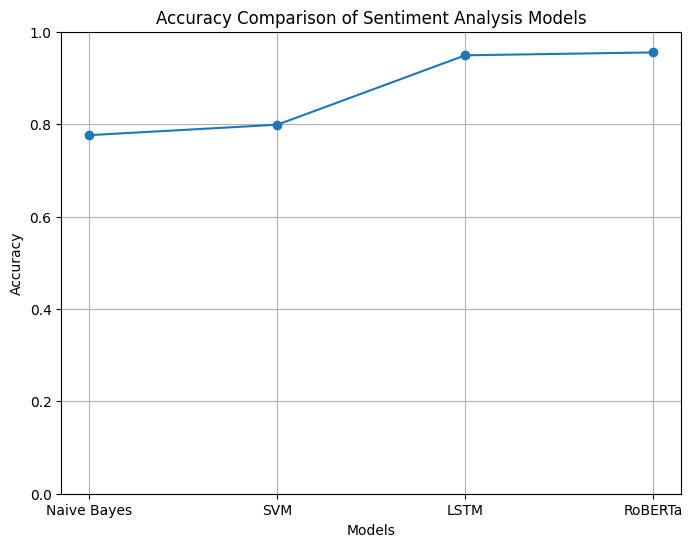

In [ ]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "SVM", "LSTM", "RoBERTa"]
accuracies = [nb_accuracy, svm_accuracy, lstm_accuracy, roberta_accuracy]

plt.figure(figsize=(8,6))

plt.plot(models, accuracies, marker='o')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Sentiment Analysis Models")

plt.ylim(0,1)

plt.grid(True)

plt.show()

### ROC Curve

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 228s 182ms/step


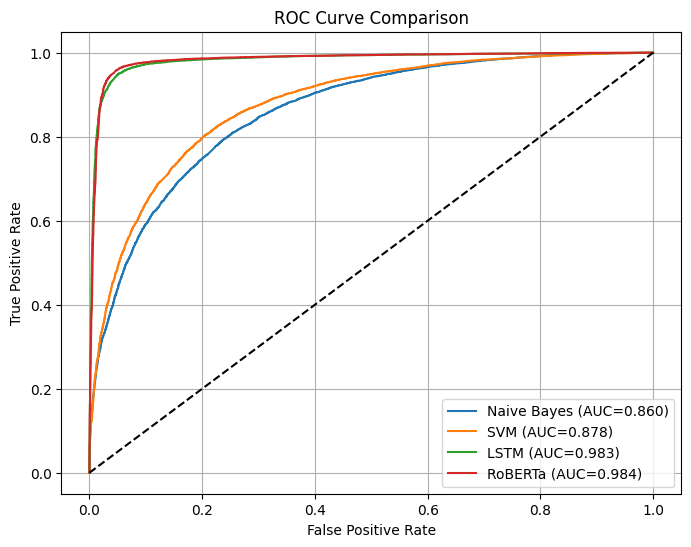

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# probabilities
nb_probs = nb_model.predict_proba(X_test_vec)[:,1]

svm_probs = svm_model.decision_function(X_test_vec)

lstm_probs = lstm_model.predict(X_test_pad).ravel()

roberta_probs = predictions.predictions[:,1]

# ROC curves
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_probs)
fpr_roberta, tpr_roberta, _ = roc_curve(y_test, roberta_probs)

# AUC
roc_nb = auc(fpr_nb, tpr_nb)
roc_svm = auc(fpr_svm, tpr_svm)
roc_lstm = auc(fpr_lstm, tpr_lstm)
roc_roberta = auc(fpr_roberta, tpr_roberta)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={roc_nb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={roc_svm:.3f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_lstm:.3f})")
plt.plot(fpr_roberta, tpr_roberta, label=f"RoBERTa (AUC={roc_roberta:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()

plt.show()

### Precision

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
nb_pred = nb_model.predict(X_test_vec)

svm_pred = svm_model.predict(X_test_vec)

lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

roberta_pred = preds

precision_nb = precision_score(y_test, nb_pred)

precision_svm = precision_score(y_test, svm_pred)

precision_lstm = precision_score(y_test, lstm_pred)

precision_roberta = precision_score(y_test, roberta_pred)

recall_nb = recall_score(y_test, nb_pred)

recall_svm = recall_score(y_test, svm_pred)

recall_lstm = recall_score(y_test, lstm_pred)

recall_roberta = recall_score(y_test, roberta_pred)

# F1-score
f1_nb = f1_score(y_test, nb_pred)
f1_svm = f1_score(y_test, svm_pred)
f1_lstm = f1_score(y_test, lstm_pred)
f1_roberta = f1_score(y_test, roberta_pred)


# Print results
print("Naive Bayes  - Precision:", precision_nb, " Recall:", recall_nb, " F1:", f1_nb)

print("SVM          - Precision:", precision_svm, " Recall:", recall_svm, " F1:", f1_svm)

print("LSTM         - Precision:", precision_lstm, " Recall:", recall_lstm, " F1:", f1_lstm)

print("RoBERTa      - Precision:", precision_roberta, " Recall:", recall_roberta, " F1:", f1_roberta)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 154s 123ms/step
Naive Bayes  - Precision: 0.7765551200884333  Recall: 0.774221019937882  F1: 0.7753863134657837
SVM          - Precision: 0.7900452929430672  Recall: 0.8126440236449254  F1: 0.8011853315224102
LSTM         - Precision: 0.9492553778268064  Recall: 0.9483518685502454  F1: 0.9488034080942238
RoBERTa      - Precision: 0.953300404131118  Recall: 0.9571686203787195  F1: 0.9552305961754781


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 123s 98ms/step


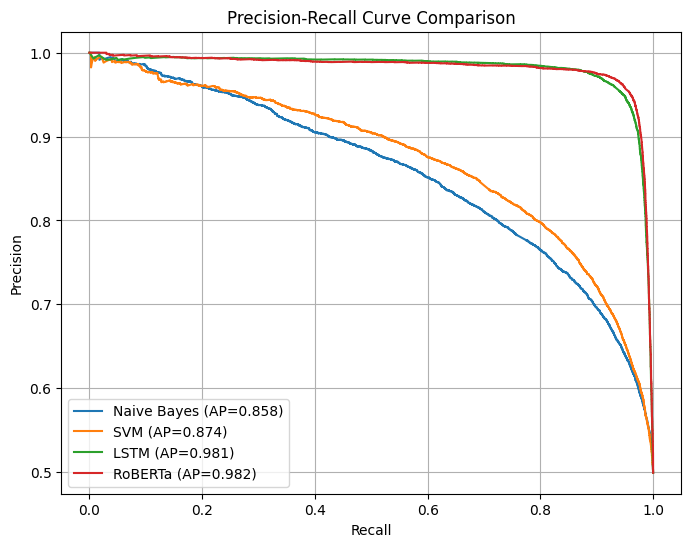

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probability scores
nb_probs = nb_model.predict_proba(X_test_vec)[:, 1]
svm_probs = svm_model.decision_function(X_test_vec)
lstm_probs = lstm_model.predict(X_test_pad).ravel()
roberta_probs = predictions.predictions[:, 1]

# Calculate precision-recall curves
precision_nb, recall_nb, _ = precision_recall_curve(y_test, nb_probs)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_probs)
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test, lstm_probs)
precision_roberta, recall_roberta, _ = precision_recall_curve(y_test, roberta_probs)

# Average precision scores
ap_nb = average_precision_score(y_test, nb_probs)
ap_svm = average_precision_score(y_test, svm_probs)
ap_lstm = average_precision_score(y_test, lstm_probs)
ap_roberta = average_precision_score(y_test, roberta_probs)

# Plot all curves
plt.figure(figsize=(8,6))

plt.plot(recall_nb, precision_nb, label=f"Naive Bayes (AP={ap_nb:.3f})")
plt.plot(recall_svm, precision_svm, label=f"SVM (AP={ap_svm:.3f})")
plt.plot(recall_lstm, precision_lstm, label=f"LSTM (AP={ap_lstm:.3f})")
plt.plot(recall_roberta, precision_roberta, label=f"RoBERTa (AP={ap_roberta:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.show()